# 1.1 Vectors and Linear Combinations

*Following Strang, G. (2023). Introduction to Linear Algebra (6th ed.). Wellesley-Cambridge Press, Section 1.1.*

## Index
1. [What is a Vector?](#1)
2. [Two Basic Operations: Scalar Multiplication and Addition](#2)
3. [Linear Combinations and the Four Special Cases](#3)
4. [Span: Plane or Line?](#4)
5. [Two Questions](#5)
6. [Solving cv + dw = b](#6)
7. [Linear Independence and Invertibility](#7)
8. [The Formal Definition of a Matrix](#8)
9. [Generalizing to Ax = b](#9)
10. [When Elimination Fails](#10)
11. [Vectors in Three Dimensions and the Identity Matrix](#11)
12. [Why the Combinations Fill a Flat Plane](#12)
13. [References](#13)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math_study.plotting.vectors import (
    plot_vectors_2d,
    plot_vector_addition,
    plot_scalar_multiplication,
    plot_span_2d,
)
from math_study.plotting.systems import plot_lines
from math_study.plotting.three_d import (
    plot_plane_span_3d,
    plot_vectors_3d,
)

<a id="1"></a>
## 1. What is a Vector?

A **vector** is an ordered list of numbers. The number of entries is its **dimension**.

Three equivalent ways to think about it:

| View | Description |
|---|---|
| **Arrow** | A directed segment from the origin to a point; length = magnitude, direction = the arrow's heading |
| **Point** | The vector is the coordinate itself |
| **Data** | A list of measurements or features, as used in machine learning and data science |

Order matters (`[2,3] ≠ [3,2]`), and vectors of different dimensions cannot be combined.


In [2]:
v = np.array([2, 3])
print("v =", v, " dimension:", v.shape[0])


v = [2 3]  dimension: 2


<a id="2"></a>
## 2. Two Basic Operations

Linear algebra is built from exactly two operations on vectors:

$$
\text{Scalar multiplication: } \quad cv
\qquad\qquad
\text{Addition: } \quad v + w
$$

In NumPy, scalar multiplication broadcasts the scalar across the array and addition acts elementwise, so neither operation needs an explicit loop:


In [3]:
v = np.array([2, 3])
w = np.array([1, 5])
c = 3

cv = c * v         # scalar multiplication via broadcasting
v_plus_w = v + w    # elementwise addition

print("c * v   =", cv)
print("v + w   =", v_plus_w)


c * v   = [6 9]
v + w   = [3 8]


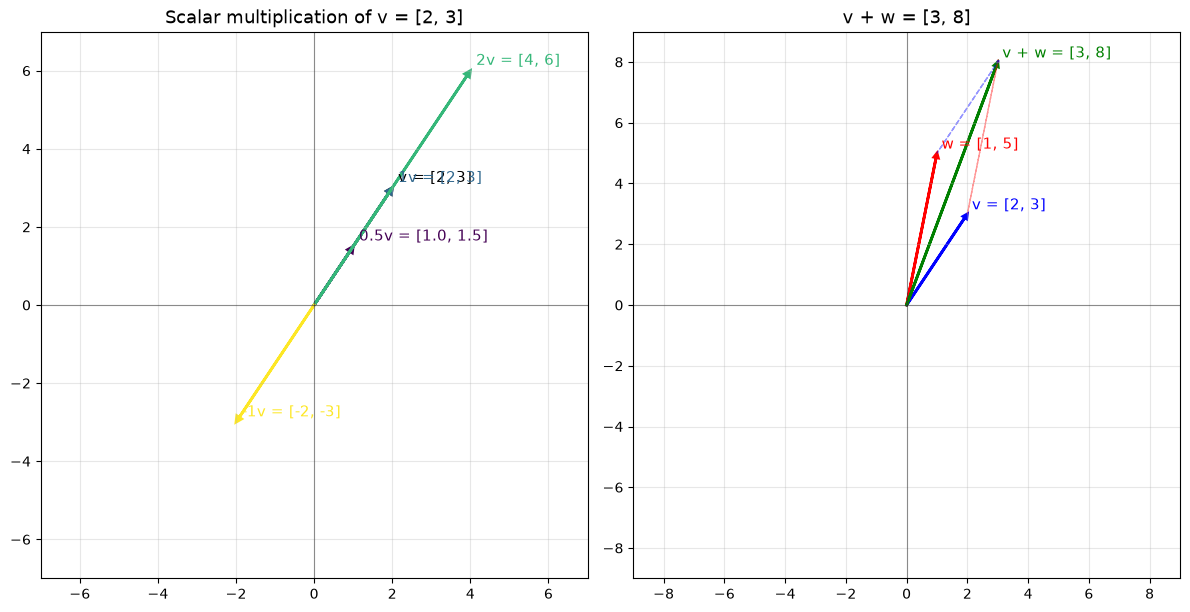

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_scalar_multiplication(v, [0.5, 1, 2, -1], ax=axes[0])
plot_vector_addition(v, w, ax=axes[1])
plt.tight_layout()
plt.show()


### The Four Special Combinations

Before generalizing, it is worth naming four combinations of `v` and `w` that recur constantly:

| Combination | Result | Meaning |
|---|---|---|
| `1v + 1w` | `v + w` | sum of vectors |
| `1v - 1w` | `v - w` | difference of vectors |
| `0v + 0w` | zero vector | the trivial combination |
| `cv + 0w` | `cv` | stays in the direction of `v` alone |


In [5]:
special_cases = {
    "1v + 1w": 1*v + 1*w,
    "1v - 1w": 1*v - 1*w,
    "0v + 0w": 0*v + 0*w,
    "cv + 0w (c=3)": 3*v + 0*w,
}
for name, result in special_cases.items():
    print(f"{name:15s} = {result}")


1v + 1w         = [3 8]
1v - 1w         = [ 1 -2]
0v + 0w         = [0 0]
cv + 0w (c=3)   = [6 9]


<a id="3"></a>
## 3. Linear Combinations

A **linear combination** of `v` and `w` is any vector of the form

$$
cv + dw
$$

for real numbers `c` and `d`. Letting `c` and `d` range over all real numbers produces the set of all possible combinations, called the **span** of `v` and `w`:

$$
\operatorname{span}\{v, w\} = \{\,cv + dw : c, d \in \mathbb{R}\,\}
$$


In [6]:
def linear_combination(c, v, d, w):
    return c * v + d * w

v = np.array([2, 1])
w = np.array([1, 2])

for c, d in [(1, 1), (2, 0), (0, 2), (3, 2), (-1, 1)]:
    print(f"{c}*v + {d}*w = {linear_combination(c, v, d, w)}")


1*v + 1*w = [3 3]
2*v + 0*w = [4 2]
0*v + 2*w = [2 4]
3*v + 2*w = [8 7]
-1*v + 1*w = [-1  1]


<a id="4"></a>
## 4. Span: Plane or Line?

If `v` and `w` point in different directions, every combination `cv + dw` fills the entire plane.
If `w` is a multiple of `v`, so that both vectors lie on one line through the origin, then every combination stays on that line, however `c` and `d` are chosen.


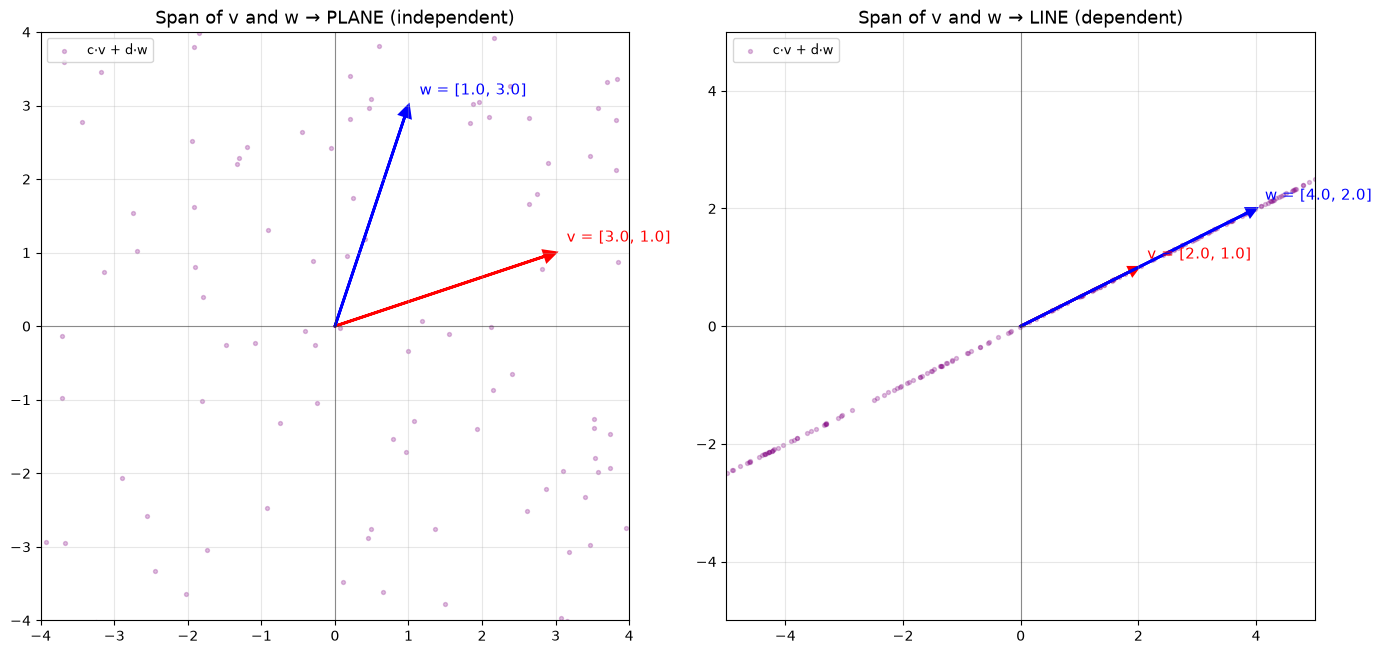

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Independent vectors -> fill a plane
plot_span_2d([3, 1], [1, 3], ax=axes[0])

# Dependent vectors -> collapse to a line  (w = 2v)
plot_span_2d([2, 1], [4, 2], ax=axes[1])

plt.tight_layout()
plt.show()


<a id="5"></a>
## 5. Two Questions

Every linear algebra problem in this chapter comes back to two questions about a linear combination `cv + dw`:

1. **Describe all combinations** `cv + dw`. Do they fill a plane, or collapse onto a line? *(the span question, answered in Section 4)*
2. **Find the numbers** `c` and `d` that produce one specific target combination `cv + dw = b`. *(a system of two equations, taken up in the next section)*

The first question asks about the set of all reachable vectors; the second asks whether one particular target can be reached.


<a id="6"></a>
## 6. Solving cv + dw = b

Take `v = [2, 1]`, `w = [1, 2]`, and target `b = [8, 7]`. The same problem can be stated in three equivalent ways:

**Column picture:** find `c` and `d` such that the combination of columns equals `b`:
$$
c\begin{bmatrix}2\\1\end{bmatrix} + d\begin{bmatrix}1\\2\end{bmatrix} = \begin{bmatrix}8\\7\end{bmatrix}
$$

**Row picture:** two ordinary equations in the unknowns `c` and `d`:
$$
2c + d = 8 \qquad\qquad c + 2d = 7
$$

**Matrix form:** the same system packed into one object, `Ax = b`:
$$
\begin{bmatrix}2 & 1\\1 & 2\end{bmatrix}\begin{bmatrix}c\\d\end{bmatrix} = \begin{bmatrix}8\\7\end{bmatrix}
$$

All three are the same problem written differently. The matrix form is the one that generalizes to many vectors and unknowns, which is why matrices deserve careful definition.


### 6.1 Solving Systems of Linear Equations using Matrices

Two equations are easy to solve by inspection. Larger systems are not, so it pays to learn techniques that scale.

NumPy's linear algebra module solves the whole system at once with `np.linalg.solve(A, b)`. The matrix `A` holds one equation per row; its columns correspond to the unknowns `x₁, ..., xₙ`, and `b` is a 1-D array with the right-hand side of each equation. The call returns `x` directly. Full documentation: [numpy.linalg.solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html).

Convenient, yes. But calling a function reveals little about what happens inside, so this section solves the same system two more times: by hand with elimination, then in code following the same steps.

In [8]:
A = np.array([[2, 1],
              [1, 2]])
b = np.array([8, 7])

x = np.linalg.solve(A, b)   # x = [c, d]
c, d = x
print(f"c = {c}, d = {d}")

# sanity check: does c*v + d*w really reconstruct b?
v, w = A[:, 0], A[:, 1]
print("c*v + d*w =", c*v + d*w, " target b =", b)


c = 3.0, d = 2.0
c*v + d*w = [8. 7.]  target b = [8 7]


### 6.2 Solving by Hand: the Elimination Method

The elimination method uses two legal moves on equations:

- multiply an equation by any nonzero number
- add or subtract one equation from another

The goal is to eliminate one variable from one equation, which leaves a single unknown that can be read off directly.

Start from the system above:

$$
\begin{cases} 2c + d = 8 \\ c + 2d = 7 \end{cases}
$$

Multiply the second equation by 2 and subtract the first equation from it. The `c` terms cancel:

$$
2c + 4d = 14 \quad\xrightarrow{\;-\,(2c+d=8)\;}\quad 3d = 6 \;\Rightarrow\; d = 2
$$

Substitute `d = 2` into the first equation:

$$
2c + 2 = 8 \;\Rightarrow\; c = 3
$$

The solution is `c = 3, d = 2`, the same one `np.linalg.solve` found.

In [9]:
# check the hand-computed answer
print("3*v + 2*w =", 3*np.array([2, 1]) + 2*np.array([1, 2]), " target b =", np.array([8, 7]))

3*v + 2*w = [8 7]  target b = [8 7]


### 6.3 Preparing Elimination in Code

Representing the system in matrix form as $Ax = b$, the same moves become operations on rows. Stack `A` and `b` side by side into one augmented matrix with `np.hstack`. Note the reshaping: `b` was defined with shape `(2,)`, and to stack it with the 2×2 matrix it needs the shape `(2, 1)`.

Rows are extracted with plain indexing. Python counts from zero, so `A_system[1]` is the second equation.

In [10]:
A_system = np.hstack((A, b.reshape((2, 1))))
print(A_system)
print()
print("second equation (index 1):", A_system[1])

[[2 1 8]
 [1 2 7]]

second equation (index 1): [1 2 7]


### 6.4 Elimination in Code

Copy the augmented matrix first so the original stays unchanged. Then repeat the hand computation as row operations: double the second row, subtract the first row from it, and scale the result so its leading coefficient becomes 1.

In [11]:
A_system_res = A_system.copy()

A_system_res[1] = 2 * A_system_res[1] - A_system_res[0]   # eliminate c from equation 2
print(A_system_res)

A_system_res[1] = (1 / 3) * A_system_res[1]               # leading coefficient -> 1
print(A_system_res)

[[2 1 8]
 [0 3 6]]
[[2 1 8]
 [0 1 2]]


Read the bottom row as `0c + 1d = 2`, so `d = 2`. Substituting into the top row, `2c + d = 8`, gives `c = 3`. Doing exactly that with array indexing:

In [12]:
d = A_system_res[1, 2]
c = (A_system_res[0, 2] - A_system_res[0, 1] * d) / A_system_res[0, 0]
print(f"elimination gives    c = {c}, d = {d}")
print("np.linalg.solve gave", np.linalg.solve(A, b))

elimination gives    c = 3.0, d = 2
np.linalg.solve gave [3. 2.]


### 6.5 Graphical Representation of the Solution

A linear equation in two unknowns draws a line: every point `(c, d)` on that line satisfies the equation. A system of two equations is therefore two lines, and the solution is the single point where both hold at once, the intersection.

The next cell plots both equations of the augmented matrix and marks that point. The plotting function lives in `math_study.plotting.systems`, so later sections can reuse it. Its internals do not matter here.

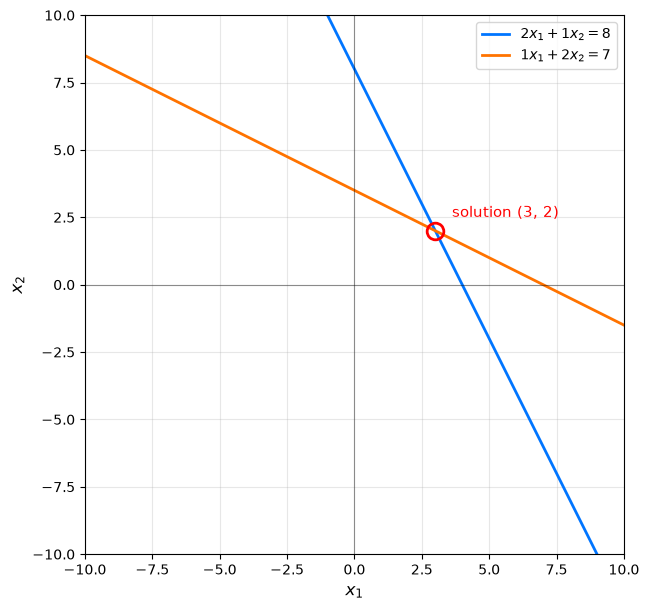

In [13]:
plot_lines(A_system)
plt.show()

<a id="7"></a>
## 7. Linear Independence and Invertibility

If `v`, `w`, and the zero vector are *not* all on the same line, there is exactly **one** solution `(c, d)` for any target `b`. In that case:

- `v` and `w` are **linearly independent**
- the matrix `A = [v w]` is **invertible**

If instead `w` is a multiple of `v`, they are **dependent** and `A` is **singular** (not invertible); Section 10 covers what happens then.

A quick numerical check for the 2×2 case: `A` is invertible exactly when its determinant is nonzero.


In [14]:
A_independent = np.array([[2, 1], [1, 2]])
A_dependent   = np.array([[2, 1], [4, 2]])   # second column = 2 * first column

print("det(independent A) =", np.linalg.det(A_independent), " -> invertible")
print("det(dependent A)   =", np.linalg.det(A_dependent),   " -> singular")


det(independent A) = 2.9999999999999996  -> invertible
det(dependent A)   = 0.0  -> singular


<a id="8"></a>
## 8. The Formal Definition of a Matrix

Linear algebra is not limited to two vectors in two dimensions. In general we have `n` vectors `v₁, v₂, ..., vₙ`, each with `m` components. Placed side by side as columns, they form an **m × n matrix**:

$$
A = \begin{bmatrix} v_1 & v_2 & \cdots & v_n \end{bmatrix}
\qquad (m \text{ rows}, \ n \text{ columns})
$$

In NumPy, `np.column_stack` builds the matrix from its columns, and slicing a column back out (`A[:, j]`) recovers the original vector `vⱼ`. Going back and forth between the two forms shows concretely that a matrix can be read as a bundle of column vectors.


In [15]:
v1 = np.array([2, 4, 1])
v2 = np.array([1, 3, 0])

# Build the matrix FROM its columns (m=3, n=2)
A = np.column_stack([v1, v2])
print("A =\n", A)
print("shape (m rows, n cols):", A.shape)

# Recover a column vector FROM the matrix
print("A[:, 0] recovers v1:", A[:, 0])
print("A[:, 1] recovers v2:", A[:, 1])


A =
 [[2 1]
 [4 3]
 [1 0]]
shape (m rows, n cols): (3, 2)
A[:, 0] recovers v1: [2 4 1]
A[:, 1] recovers v2: [1 3 0]


<a id="9"></a>
## 9. Generalizing to Ax = b

With matrices available, the two questions from Section 5 apply unchanged to any number of vectors:

1. **Describe all combinations** $Ax = x_1v_1 + x_2v_2 + \cdots + x_nv_n$ of the columns of `A`. *(this set is called the column space of A)*
2. **Find `x`** such that $Ax = b$ for a desired output vector `b`.

Setting `m = n = 2` turns `Ax = b` back into `cv + dw = b` from Section 6, which is just the smallest case of the general pattern.


In [16]:
# n=2 vectors, m=3 dimensions each -> A is 3x2 (matches v1, v2 from Section 8)
A = np.column_stack([v1, v2])
x = np.array([2, -1])   # x1=2, x2=-1

Ax = A @ x                      # matrix-vector product = combination of columns
manual = x[0]*v1 + x[1]*v2      # same thing, written out by hand

print("A @ x        =", Ax)
print("x1*v1 + x2*v2 =", manual)


A @ x        = [3 5 2]
x1*v1 + x2*v2 = [3 5 2]


<a id="10"></a>
## 10. When Elimination Fails

If `v` and `w` lie on the same line through the origin, they are dependent, and every combination `cv + dw` stays on that line. If the target `b` lies *off* that line, there is **no solution**.

For an exactly singular matrix, `np.linalg.solve` raises a `LinAlgError`, which is a useful safety check in larger programs.


In [17]:
A_dependent = np.array([[2, 1],
                        [4, 2]])   # column 2 = 2 * column 1 -> same line
b_off_line = np.array([8, 3])     # not reachable by any c, d

try:
    np.linalg.solve(A_dependent, b_off_line)
except np.linalg.LinAlgError as e:
    print("No solution -- matrix is singular:", e)


No solution -- matrix is singular: Singular matrix


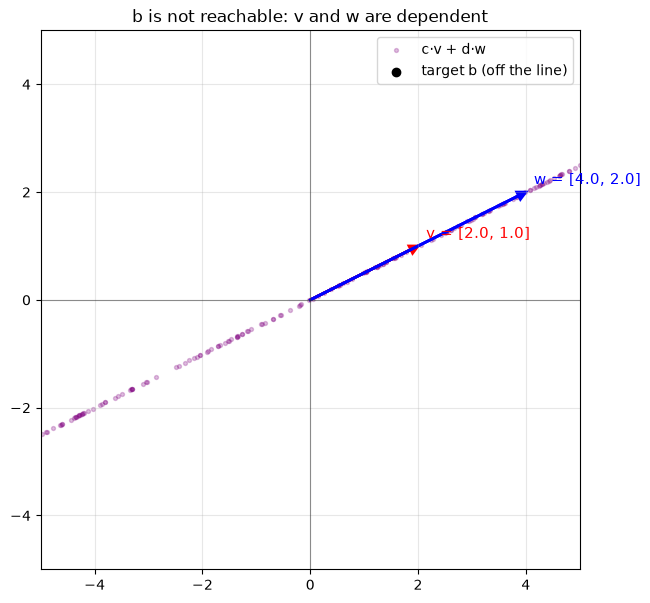

In [18]:
plot_span_2d([2, 1], [4, 2])
plt.scatter([8], [3], color="black", zorder=5, label="target b (off the line)")
plt.legend()
plt.title("b is not reachable: v and w are dependent")
plt.show()


### 10.1 When Elimination Produces a Contradiction

Dependent vectors fail in a way worth seeing in the arithmetic. Take `v = [1, 2]`, `w = [3, 6]`, and target `b = [0, 2]`, so `w = 3v` lies on the same line through the origin while the target does not.

With `v` and `w` as the columns of `A`, the system `cv + dw = b` reads:

$$
\begin{cases} c + 3d = 0 \\ 2c + 6d = 2 \end{cases}
$$

Multiply the first equation by 2 and subtract the second from it. Elimination now removes not only `c` but also `d`, leaving `0 = -2`. No pair `(c, d)` survives that statement. This is the algebraic face of "the target is off the line".

In [19]:
v = np.array([1, 2])
w = np.array([3, 6])          # w = 3v -> same line
b = np.array([0, 2])          # off the line

A_aug = np.hstack((np.column_stack([v, w]), b.reshape((2, 1))))
print("system:\n", A_aug)

A_aug_res = A_aug.copy()
A_aug_res[1] = 2 * A_aug_res[0] - A_aug_res[1]
print("\nafter eliminating:\n", A_aug_res)
print("\nlast equation reads 0*c + 0*d = -2 -> impossible")

system:
 [[1 3 0]
 [2 6 2]]

after eliminating:
 [[ 1  3  0]
 [ 0  0 -2]]

last equation reads 0*c + 0*d = -2 -> impossible


### 10.2 A Zero Pivot: Exchanging Equations

Elimination can stall even for independent vectors. Consider:

$$
\begin{cases} 0c + 2d = 4 \\ 3c - d = 5 \end{cases}
$$

The zero coefficient looks dangerous because there is nothing to eliminate with. The fix costs nothing: exchange the two equations and elimination proceeds normally. This move is called a **row exchange**, and `np.linalg.solve` performs one automatically whenever a pivot comes out zero.

In [20]:
A_zero_pivot = np.array([[0.0, 2.0],
                         [3.0, -1.0]])
b_zp = np.array([4.0, 5.0])

A_zp_sys = np.hstack((A_zero_pivot, b_zp.reshape((2, 1))))
print("as given:\n", A_zp_sys)

A_zp_sys[[0, 1]] = A_zp_sys[[1, 0]]       # exchange the two equations
print("\nafter row exchange:\n", A_zp_sys)

d = A_zp_sys[1, 2] / A_zp_sys[1, 1]
c = (A_zp_sys[0, 2] - A_zp_sys[0, 1] * d) / A_zp_sys[0, 0]
print(f"\nback-substitution:  c = {c}, d = {d}")
print("np.linalg.solve:   ", np.linalg.solve(A_zero_pivot, b_zp))

as given:
 [[ 0.  2.  4.]
 [ 3. -1.  5.]]

after row exchange:
 [[ 3. -1.  5.]
 [ 0.  2.  4.]]

back-substitution:  c = 2.3333333333333335, d = 2.0
np.linalg.solve:    [2.33333333 2.        ]


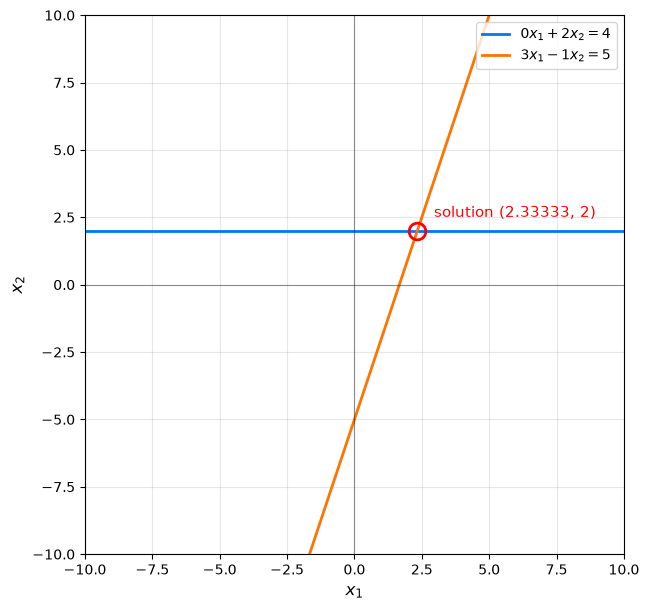

In [21]:
plot_lines(np.hstack((A_zero_pivot, b_zp.reshape((2, 1)))))
plt.show()

<a id="11"></a>
## 11. Vectors in Three Dimensions and the Identity Matrix

Give `v` and `w` three components each and almost nothing about combinations changes. What changes is coverage: two vectors in $\mathbb{R}^3$ produce at most a plane of combinations. No choice of coefficients fills the whole space. None of this is linear dependence; there are simply not enough vectors. Filling $\mathbb{R}^3$ takes three independent vectors.

The simplest independent triple points along the axes:

$$
i = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \qquad
j = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \qquad
k = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}
$$

Every 3D vector is a combination of them, and the coefficients are just its components: $v = v_1 i + v_2 j + v_3 k$. Rebuild `v1 = [2, 4, 1]` from Section 8 that way:

In [22]:
i = np.array([1, 0, 0])
j = np.array([0, 1, 0])
k = np.array([0, 0, 1])

print("v1            =", v1)
print("2*i + 4*j + k =", 2*i + 4*j + 1*k)

v1            = [2 4 1]
2*i + 4*j + k = [2 4 1]


Written out, the combination $v = v_1 i + v_2 j + v_3 k$ is a matrix product:

$$
v =
\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
\begin{bmatrix} v_1 \\ v_2 \\ v_3 \end{bmatrix}
$$

That 3×3 matrix is the **identity matrix** $I$. Multiplying by it leaves every vector unchanged, $Iv = v$. It plays the role for matrices that the number 1 plays for ordinary numbers.

In [23]:
I = np.eye(3)
print("I =\n", I)
print("I @ v1 =", I @ v1)

I =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
I @ v1 = [2. 4. 1.]


Combinations only make sense within one space. Adding a 2D vector to a 3D vector has no definition, and NumPy refuses outright:

In [24]:
u_2d = np.array([1, 1])
try:
    u_2d + v1
except ValueError as err:
    print("cannot combine different dimensions:", err)

cannot combine different dimensions: operands could not be broadcast together with shapes (2,) (3,) 


The plot shows `v1` and `v2` together with every combination $cv + dw$: a flat sheet inside $\mathbb{R}^3$. Rotating the view makes it obvious that the whole space is never reached.

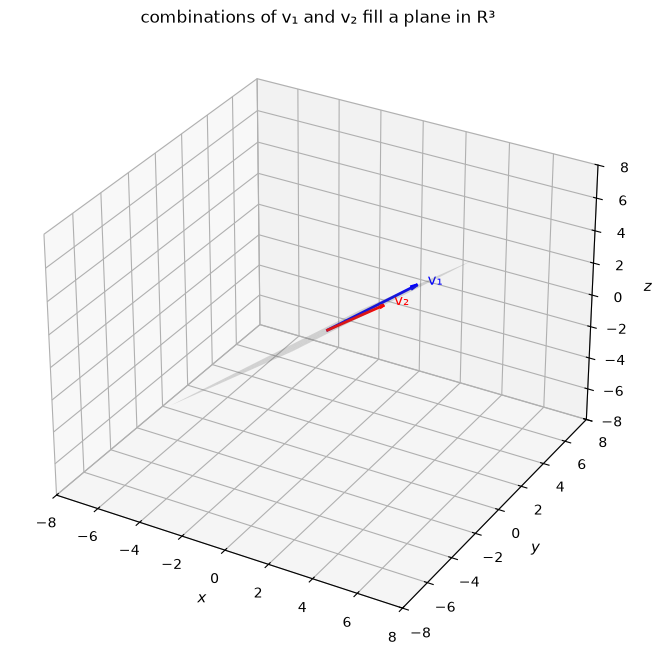

In [25]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
plot_plane_span_3d(v1, v2, extent=1, ax=ax)
plot_vectors_3d([v1, v2], labels=["v₁", "v₂"], ax=ax)
ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_zlim(-8, 8)
ax.set_title("combinations of v₁ and v₂ fill a plane in R³")
plt.show()

<a id="12"></a>
## 12. Why the Combinations Fill a Flat Plane

Section 11 showed the combinations forming a plane. A short argument says why that surface has to be flat.

Pick any two points on the surface, $P = cv + dw$ and $Q = Cv + Dw$. Their midpoint is

$$
h = \tfrac{1}{2}(P + Q) = \tfrac{c+C}{2}\,v + \tfrac{d+D}{2}\,w,
$$

which is itself a combination of $v$ and $w$. So the midpoint of any two surface points lies on the surface again. Nothing can bulge between two points when their midpoint stays on the surface, and that is exactly what flatness means. Section 1.2 completes the argument.

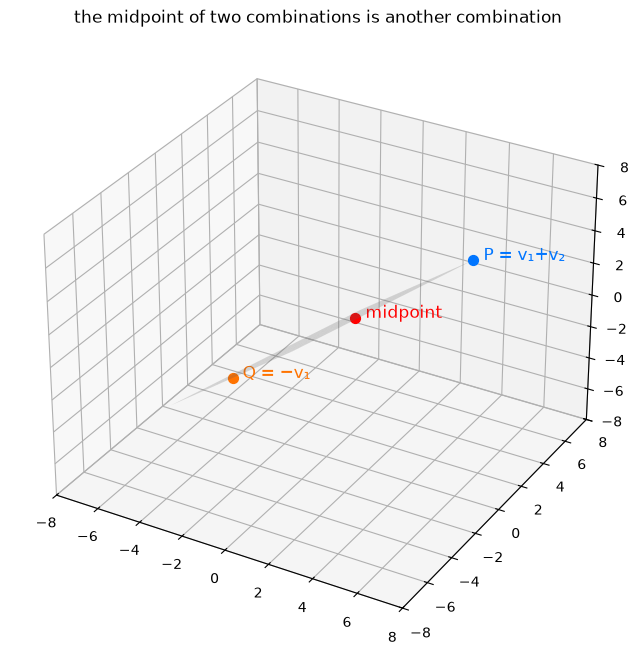

In [26]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
plot_plane_span_3d(v1, v2, extent=1, ax=ax)

P = v1 + v2
Q = -v1
midpoint = (P + Q) / 2

for point, name, color in [(P, "P = v₁+v₂", "#0075ff"),
                           (Q, "Q = −v₁", "#ff7300"),
                           (midpoint, "midpoint", "#ff0000")]:
    ax.scatter(point[0], point[1], point[2], color=color, s=50)
    ax.text(point[0], point[1], point[2], "  " + name, color=color, fontsize=12)

ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_zlim(-8, 8)
ax.set_title("the midpoint of two combinations is another combination")
plt.show()

<a id="13"></a>
## 13. References

- Strang, G. (2023). *Introduction to Linear Algebra* (6th ed.). Wellesley-Cambridge Press. Section 1.1, pp. 1–4.
- NumPy documentation: [numpy.linalg.solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html).